## IMPORTS

In [ ]:
import warningsimport pandas as pdimport torchfrom torch import nnfrom hazm import Normalizer, word_tokenize, stopwords_listfrom collections import Counterimport stringfrom torch.utils.data import Dataset, DataLoaderfrom sklearn.metrics import precision_score, recall_score, f1_scorefrom sklearn.model_selection import train_test_splitfrom timeit import default_timer as timerimport matplotlib.pyplot as pltfrom tqdm import tqdmimport textwrapwarnings.filterwarnings('ignore')

## Device

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Timer

In [3]:
def print_train_time(start: float, end : float, device: torch.device = None):    total_time = end - start    print(f"Train time on {device}: {total_time/60:.3f} minutes\n\n")    return total_time

## DATA

In [4]:
emails = pd.read_csv("data/emails.csv")

In [5]:
emails.head()

,text,label
0,﻿ممنون آقا سامان.\nمن پارسال اصلا آزاد شرکت نک...,ham
1,﻿سلام آقای کریمی\nبالاخره آزمونارشد تموم شد من...,ham
2,﻿درود بر حاج وحیدی بنده بعنوان یک دکتری تاریخ ...,ham
3,﻿با سلام و احترام\nضمن تقدیر از مسولین محترم ...,ham
4,﻿با سلام اینجانب یک دستگاه خودرو پراید 131 با ...,ham


## Q1: Preprocessing

In [ ]:
# Hazm componentsnormalizer = Normalizer()stopwords = set(stopwords_list())punctuations = string.punctuation + "،؛؟«»"def preprocess_persian_text(text):    # Normalize    text = normalizer.normalize(text).replace('\ufeff', '').replace('\u200c', '')    # Tokenize and clean    tokens = [        ''.join(c for c in token if c not in punctuations)        for token in word_tokenize(text)    ]    # Remove stopwords and empty tokens    return [t for t in tokens if t and t not in stopwords]# Apply preprocessingemails['processed_text_tokens'] = emails['text'].apply(preprocess_persian_text)emails['processed_text_joined'] = emails['processed_text_tokens'].apply(' '.join)for _, row in emails.head().iterrows():    print(f"Original: {row['text']}")    print(f"Processed Tokens: {row['processed_text_tokens']}")    print(f"Processed Joined: {row['processed_text_joined']}\n")

Original: ﻿ممنون آقا سامان.
من پارسال اصلا آزاد شرکت نکرده بودم و سراسری هم قبول نشدم. فقط میخواستم بدونم شرایط چطوریه واسه سال بعد. مرسی از راهنمایی هاتون.
Processed Tokens: ['ممنون', 'آقا', 'سامان', 'پارسال', 'اصلا', 'آزاد', 'شرکت', 'نکردهبودم', 'سراسری', 'قبول', 'نشدم', 'میخواستم', 'بدونم', 'شرایط', 'چطوریه', 'واسه', 'سال', 'مرسی', 'راهنمایی', 'هاتون']
Processed Joined: ممنون آقا سامان پارسال اصلا آزاد شرکت نکردهبودم سراسری قبول نشدم میخواستم بدونم شرایط چطوریه واسه سال مرسی راهنمایی هاتون

Original: ﻿سلام آقای کریمی
بالاخره آزمونارشد تموم شد من راحت شدم
یکم راهنمایی می خوام
بهترین مجله ی تخصصی زبان شناسی که بتونم اشتراک بگیرم کدومه؟
و در زمینه ی جامعه شناسی و روانشناسی زبان کتابای خوب و مرجع رو لطفا بهم معرفی کنید. صرفا به خاطر علاقه ی خودم می خوام مطالعه ی آزاد و تخصصی داشته باشم برای کنکور نیست
مرسی
دوستان دیگه هم اگه کمک کنند ممنونمی شم 
Processed Tokens: ['سلام', 'کریمی', 'بالاخره', 'آزمونارشد', 'تموم', 'راحت', 'شدم', 'یکم', 'راهنمایی', 'میخوام', 'مجلهی', 'تخصصی', 'زبانشناسی', 

In [7]:
PAD = "<PAD>"  # PaddingUNK = "<UNK>"  # Unknown

In [ ]:
# Flatten all tokenized text into one listall_tokens = [token for tokens in emails['processed_text_tokens'] for token in tokens]# Count token frequenciestoken_freq = Counter(all_tokens)# Set vocab, starting with PAD and UNKvocab = [PAD, UNK] + sorted(token_freq.keys())# Map tokens to indicestoken2idx = {token: idx for idx, token in enumerate(vocab)}# Vocab sizevocab_size = len(token2idx)print(f"Vocabulary size: {vocab_size}")

Vocabulary size: 27769


In [9]:
token2idx

{'<PAD>': 0,
 '<UNK>': 1,
 'A': 2,
 'AAAAAAAAAAM': 3,
 'AAC': 4,
 'AB': 5,
 'AC': 6,
 'ACS': 7,
 'ACTIONALLPRODUCTSBRANDF٪D': 8,
 'ACTIONOFFICE': 9,
 'ADSL': 10,
 'AFxigJ': 11,
 'AG': 12,
 'AGetyourPassport': 13,
 'AIDS': 14,
 'AIFF': 15,
 'AL': 16,
 'AM': 17,
 'AMAD': 18,
 'AMD': 19,
 'AMPANG': 20,
 'ANDOR': 21,
 'AP': 22,
 'APPLE': 23,
 'APPS': 24,
 'APPlE': 25,
 'ARM': 26,
 'ARMANI': 27,
 'ASCE': 28,
 'ASME': 29,
 'ASP': 30,
 'ASTM': 31,
 'ATI': 32,
 'ATM': 33,
 'AUX': 34,
 'AVENUE': 35,
 'AVG': 36,
 'AWSurveys': 37,
 'AX': 38,
 'AXRKhQvBZNpeK': 39,
 'Ab': 40,
 'Abbas': 41,
 'Abstract': 42,
 'Academic': 43,
 'Academy': 44,
 'Accelerator': 45,
 'Account': 46,
 'Accountکلیک': 47,
 'Acer': 48,
 'Acrobat': 49,
 'Active': 50,
 'AdSense': 51,
 'Address': 52,
 'Address٪': 53,
 'Administration': 54,
 'Adobe': 55,
 'Adobeمنتشر': 56,
 'Ads': 57,
 'AdsAffiliate': 58,
 'AdsID': 59,
 'AdsIDadstypepercent': 60,
 'AdsIDadstypepercentname٪D': 61,
 'AdsIDadstypepercentname٪DA٪A': 62,
 'AdsIDadstypep

In [ ]:
max_len = 50def tokens_to_indices(tokens, token2idx, max_len):    # Convert tokens to indices    indices = [token2idx.get(token, token2idx["<UNK>"]) for token in tokens]    # Pad or cut short    if len(indices) < max_len:        indices += [token2idx["<PAD>"]] * (max_len - len(indices))    else:        indices = indices[:max_len]    return indices# Apply conversionemails['input_ids'] = emails['processed_text_tokens'].apply(    lambda tokens: tokens_to_indices(tokens, token2idx, max_len))label_map = {"spam": 1, "ham": 0}emails['label'] = emails['label'].map(label_map)

filling missing values in labels

In [ ]:
print(emails['label'].isna().sum())  # Show how many NaNs exist

0
0


## Split

In [ ]:
# First split: train (70%)train_df, temp_df = train_test_split(    emails, test_size=0.3, stratify=emails['label'], random_state=42)# Then split temp: val (10%) vs test (20%)val_df, test_df = train_test_split(    temp_df, test_size=2/3, stratify=temp_df['label'], random_state=42)

## DataLoaders 

In [13]:
class EmailDataset(Dataset):    def __init__(self, df):        self.inputs = df['input_ids'].tolist()        self.labels = df['label'].tolist()    def __len__(self):        return len(self.inputs)    def __getitem__(self, idx):        x = torch.tensor(self.inputs[idx], dtype=torch.long)        y = torch.tensor(self.labels[idx], dtype=torch.float)        return x, y

In [14]:
# Create datasetstrain_dataset = EmailDataset(train_df)val_dataset = EmailDataset(val_df)test_dataset = EmailDataset(test_df)# Create data loadersbatch_size = 64train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)val_loader   = DataLoader(val_dataset, batch_size=batch_size)test_loader  = DataLoader(test_dataset, batch_size=batch_size)

## Q2: A simple model including:

1. an embedding layer
2. a recurrent layer
3. a fully connected layer

plus different metrics and loss plots

In [15]:
class SimpleRNNClassifier(nn.Module):    def __init__(self, vocab_size, embed_dim=100, hidden_dim=64):        super(SimpleRNNClassifier, self).__init__()        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim, padding_idx=token2idx["<PAD>"])        self.rnn = nn.RNN(input_size=embed_dim, hidden_size=hidden_dim, batch_first=True)        self.fc = nn.Linear(hidden_dim, 1)    def forward(self, x):        embedded = self.embedding(x)                # [batch_size, seq_len, embed_dim]        _, hidden = self.rnn(embedded)              # hidden: [1, batch_size, hidden_dim]        out = self.fc(hidden.squeeze(0))            # [batch_size, 1]        return out.squeeze(1)                       # [batch_size]

## Train and Validation loop

In [16]:
def train_validation(model, loss_fn, optimizer, trainloader, valloader, device, epochs=10, show_result=True):    start_time = timer()    train_losses, val_losses = [], []    train_accuracies, val_accuracies = [], []    for epoch in range(epochs):        model.train()        running_loss = 0.0        correct, total = 0, 0        for inputs, labels in tqdm(trainloader, desc=f"Epoch {epoch+1}/{epochs} - Training", leave=False):            inputs, labels = inputs.to(device), labels.to(device)            optimizer.zero_grad()            outputs = model(inputs)            loss = loss_fn(outputs, labels)            loss.backward()            optimizer.step()            running_loss += loss.item()            preds = (torch.sigmoid(outputs) > 0.5).float()            correct += (preds == labels).sum().item()            total += labels.size(0)        epoch_loss = running_loss / len(trainloader)        epoch_acc = 100. * correct / total        train_losses.append(epoch_loss)        train_accuracies.append(epoch_acc)        if show_result:            print(f'\nEpoch {epoch+1}/{epochs} - Train Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%')        # --- Validation ---        model.eval()        val_loss, val_correct, val_total = 0.0, 0, 0        all_preds, all_labels = [], []        with torch.no_grad():            for inputs, labels in valloader:                inputs, labels = inputs.to(device), labels.to(device)                outputs = model(inputs)                loss = loss_fn(outputs, labels)                val_loss += loss.item()                preds = (torch.sigmoid(outputs) > 0.5).float()                val_correct += (preds == labels).sum().item()                val_total += labels.size(0)                all_preds.extend(preds.cpu().numpy())                all_labels.extend(labels.cpu().numpy())        avg_val_loss = val_loss / len(valloader)        val_acc = 100. * val_correct / val_total        val_losses.append(avg_val_loss)        val_accuracies.append(val_acc)        if show_result:            print(f'Epoch {epoch+1}/{epochs} - Val Loss: {avg_val_loss:.4f}, Accuracy: {val_acc:.2f}%')    # Evaluation metrics on val    precision = precision_score(all_labels, all_preds)    recall = recall_score(all_labels, all_preds)    f1 = f1_score(all_labels, all_preds)    if show_result:        print(f'\nVal Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}\n')    end_time = timer()    print_train_time(start_time, end_time, device=device)    return train_losses, train_accuracies, val_losses, val_accuracies

## Prediction (Testset Evaluation)

In [17]:
def testset_prediction(model, testloader, device):    model.eval()    all_preds, all_labels = [], []    correct, total = 0, 0    with torch.no_grad():        for inputs, labels in tqdm(testloader, desc="Final Test Evaluation"):            inputs, labels = inputs.to(device), labels.to(device)            outputs = model(inputs)            preds = (torch.sigmoid(outputs) > 0.5).float()            correct += (preds == labels).sum().item()            total += labels.size(0)            all_preds.extend(preds.cpu().numpy())            all_labels.extend(labels.cpu().numpy())    test_accuracy = 100. * correct / total    precision = precision_score(all_labels, all_preds)    recall = recall_score(all_labels, all_preds)    f1 = f1_score(all_labels, all_preds)    print(f"\nTest Accuracy: {test_accuracy:.2f}%")    print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}\n")    return test_accuracy

## Visualizer

In [18]:
def plot_train_eval(train_losses, train_accuracies, val_losses, val_accuracies):    fig, axes = plt.subplots(1, 2, figsize=(20, 10))    # Plot Training and Evaluation Loss    plt.sca(axes[0])    plt.plot(train_losses, label="Training Loss", marker='o')    plt.plot(val_losses, label="Evaluation Loss", marker='s')    plt.xlabel("Epoch")    plt.ylabel("Loss")    plt.title("Training and Evaluation Loss")    plt.legend()    # Plot Training and Evaluation Accuracy    plt.sca(axes[1])    plt.plot(train_accuracies, label="Training Accuracy", marker='o')    plt.plot(val_accuracies, label="Evaluation Accuracy", marker='s')    plt.xlabel("Epoch")    plt.ylabel("Accuracy (%)")    plt.title("Training and Evaluation Accuracy")    plt.legend()    plt.tight_layout()    plt.show()

In [19]:
model = SimpleRNNClassifier(vocab_size=vocab_size).to(device)

In [20]:
loss_fn = nn.BCEWithLogitsLoss()optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [21]:
train_losses, train_accuracies, eval_losses, eval_accuracies = train_validation(model, loss_fn, optimizer, train_loader, val_loader, device, epochs=9)


Epoch 1/9 - Train Loss: 0.6962, Accuracy: 57.86%
Epoch 1/9 - Val Loss: 0.6968, Accuracy: 58.00%



Epoch 2/9 - Train Loss: 0.6475, Accuracy: 66.57%
Epoch 2/9 - Val Loss: 0.6806, Accuracy: 53.00%



Epoch 3/9 - Train Loss: 0.5960, Accuracy: 73.57%
Epoch 3/9 - Val Loss: 0.6538, Accuracy: 60.00%



Epoch 4/9 - Train Loss: 0.5271, Accuracy: 76.43%
Epoch 4/9 - Val Loss: 0.6100, Accuracy: 62.00%



Epoch 5/9 - Train Loss: 0.4223, Accuracy: 83.29%
Epoch 5/9 - Val Loss: 0.5029, Accuracy: 79.00%



Epoch 6/9 - Train Loss: 0.3047, Accuracy: 88.71%
Epoch 6/9 - Val Loss: 0.5182, Accuracy: 82.00%



Epoch 7/9 - Train Loss: 0.2676, Accuracy: 91.00%
Epoch 7/9 - Val Loss: 0.4283, Accuracy: 81.00%



Epoch 8/9 - Train Loss: 0.1998, Accuracy: 93.29%
Epoch 8/9 - Val Loss: 0.4111, Accuracy: 84.00%



Epoch 9/9 - Train Loss: 0.1664, Accuracy: 95.57%
Epoch 9/9 - Val Loss: 0.4206, Accuracy: 84.00%

Val Precision: 0.8696, Recall: 0.8000, F1-Score: 0.8333

Train time on cuda: 0.116 minutes




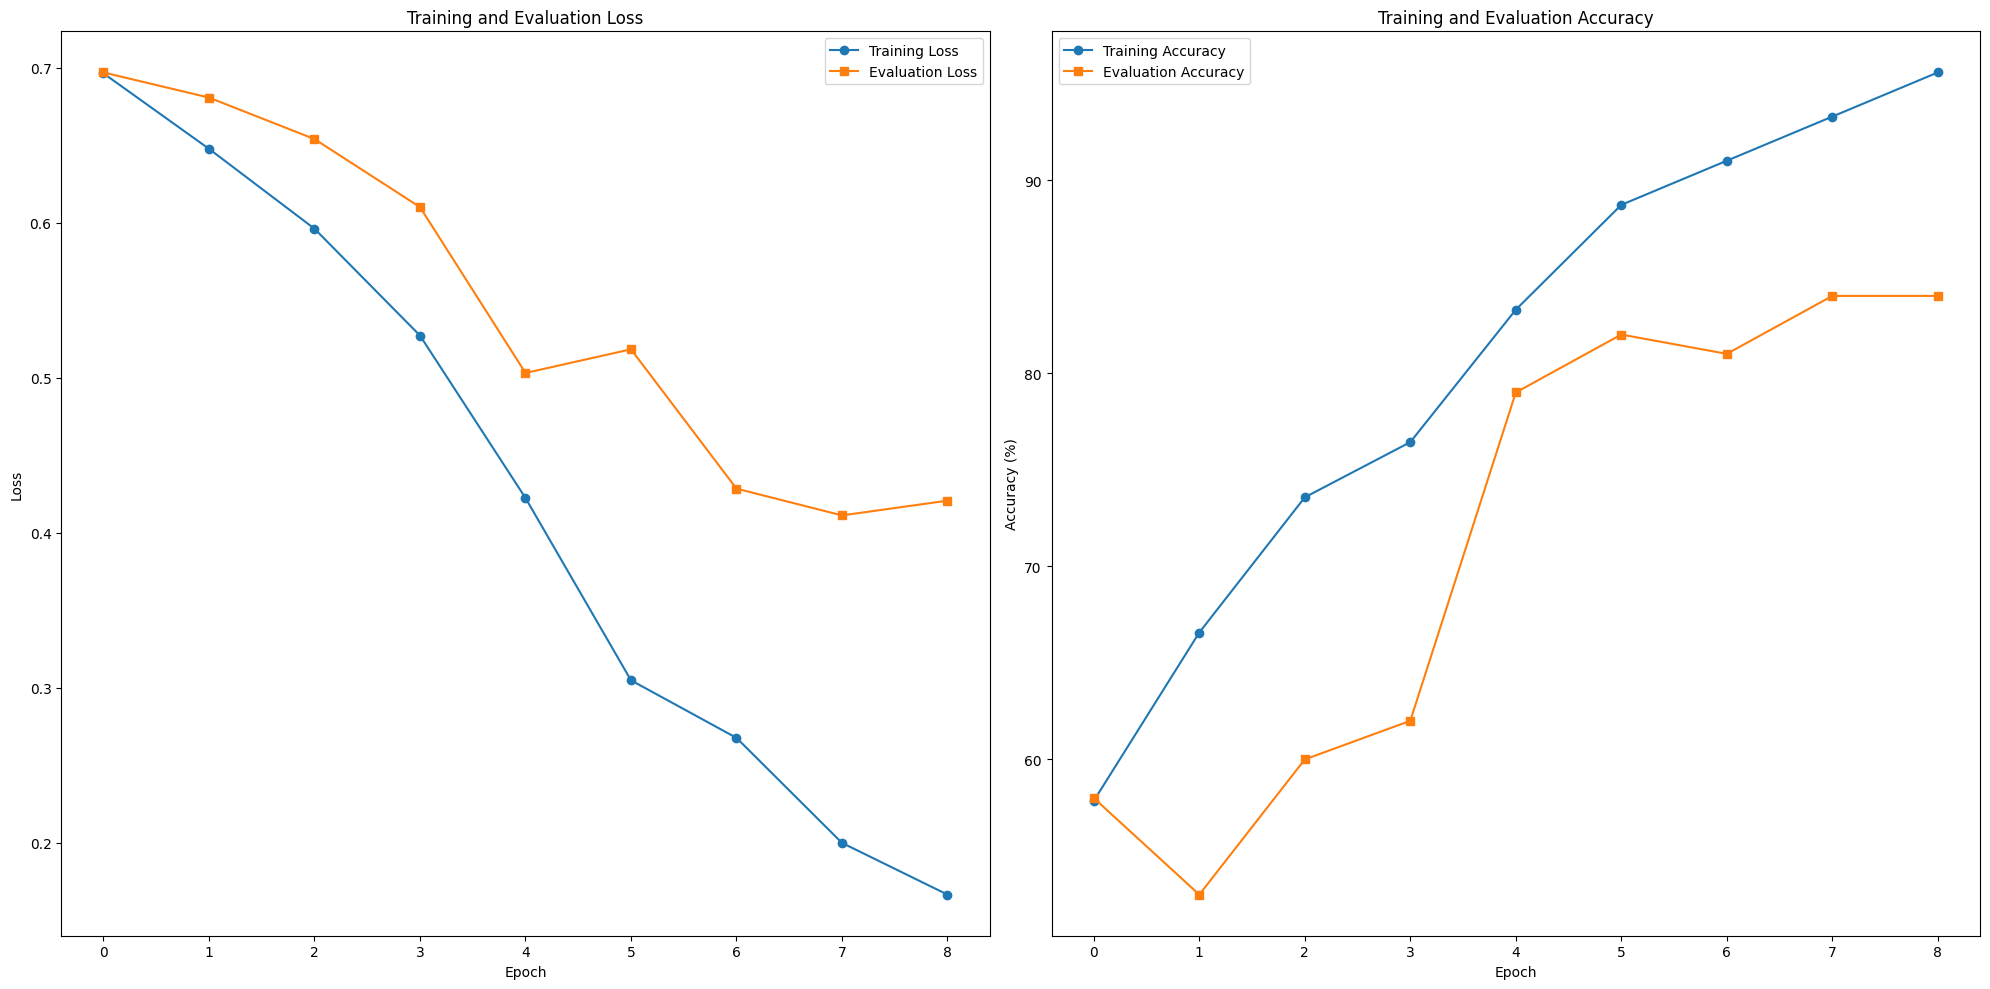

In [22]:
plot_train_eval(train_losses, train_accuracies, eval_losses, eval_accuracies)

## Q3: Replace recurrent layer with a LSTM and compare 

In [23]:
class LSTMClassifier(nn.Module):    def __init__(self, vocab_size, embed_dim = 100, hidden_dim = 64, dropout=0.0):        super(LSTMClassifier, self).__init__()        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim, padding_idx=token2idx["<PAD>"])        self.lstm = nn.LSTM(input_size=embed_dim, hidden_size=hidden_dim, batch_first=True, dropout=dropout if dropout > 0 else 0)        self.dropout = nn.Dropout(dropout)        self.fc = nn.Linear(hidden_dim, 1)    def forward(self, x):        embedded = self.embedding(x)        _, (hidden, _) = self.lstm(embedded)        hidden = self.dropout(hidden.squeeze(0))        out = self.fc(hidden)        return out.squeeze(1)

In [24]:
LSTM_model = LSTMClassifier(vocab_size=vocab_size).to(device)

In [25]:
LSTM_loss_fn = nn.BCEWithLogitsLoss()LSTM_optimizer = torch.optim.Adam(LSTM_model.parameters(), lr=0.001)

In [26]:
LSTM_train_losses, LSTM_train_accuracies, LSTM_eval_losses, LSTM_eval_accuracies = train_validation(LSTM_model, LSTM_loss_fn, LSTM_optimizer, train_loader, val_loader, device, epochs=9)testset_prediction(model, test_loader, device)


Epoch 1/9 - Train Loss: 0.6877, Accuracy: 49.00%
Epoch 1/9 - Val Loss: 0.6748, Accuracy: 73.00%



Epoch 2/9 - Train Loss: 0.6607, Accuracy: 74.43%
Epoch 2/9 - Val Loss: 0.6551, Accuracy: 73.00%



Epoch 3/9 - Train Loss: 0.6173, Accuracy: 80.29%
Epoch 3/9 - Val Loss: 0.6052, Accuracy: 73.00%



Epoch 4/9 - Train Loss: 0.5198, Accuracy: 82.00%
Epoch 4/9 - Val Loss: 0.5197, Accuracy: 75.00%



Epoch 5/9 - Train Loss: 0.3741, Accuracy: 90.43%
Epoch 5/9 - Val Loss: 0.4341, Accuracy: 84.00%


...


Epoch 8/9 - Train Loss: 0.1330, Accuracy: 97.14%
Epoch 8/9 - Val Loss: 0.3304, Accuracy: 87.00%



Epoch 9/9 - Train Loss: 0.0998, Accuracy: 99.14%
Epoch 9/9 - Val Loss: 0.3160, Accuracy: 90.00%

Val Precision: 0.9000, Recall: 0.9000, F1-Score: 0.9000

Train time on cuda: 0.171 minutes




Final Test Evaluation: 100%|██████████| 4/4 [00:00<00:00,  6.36it/s]


Test Accuracy: 85.50%
Precision: 0.8447, Recall: 0.8700, F1: 0.8571



85.5

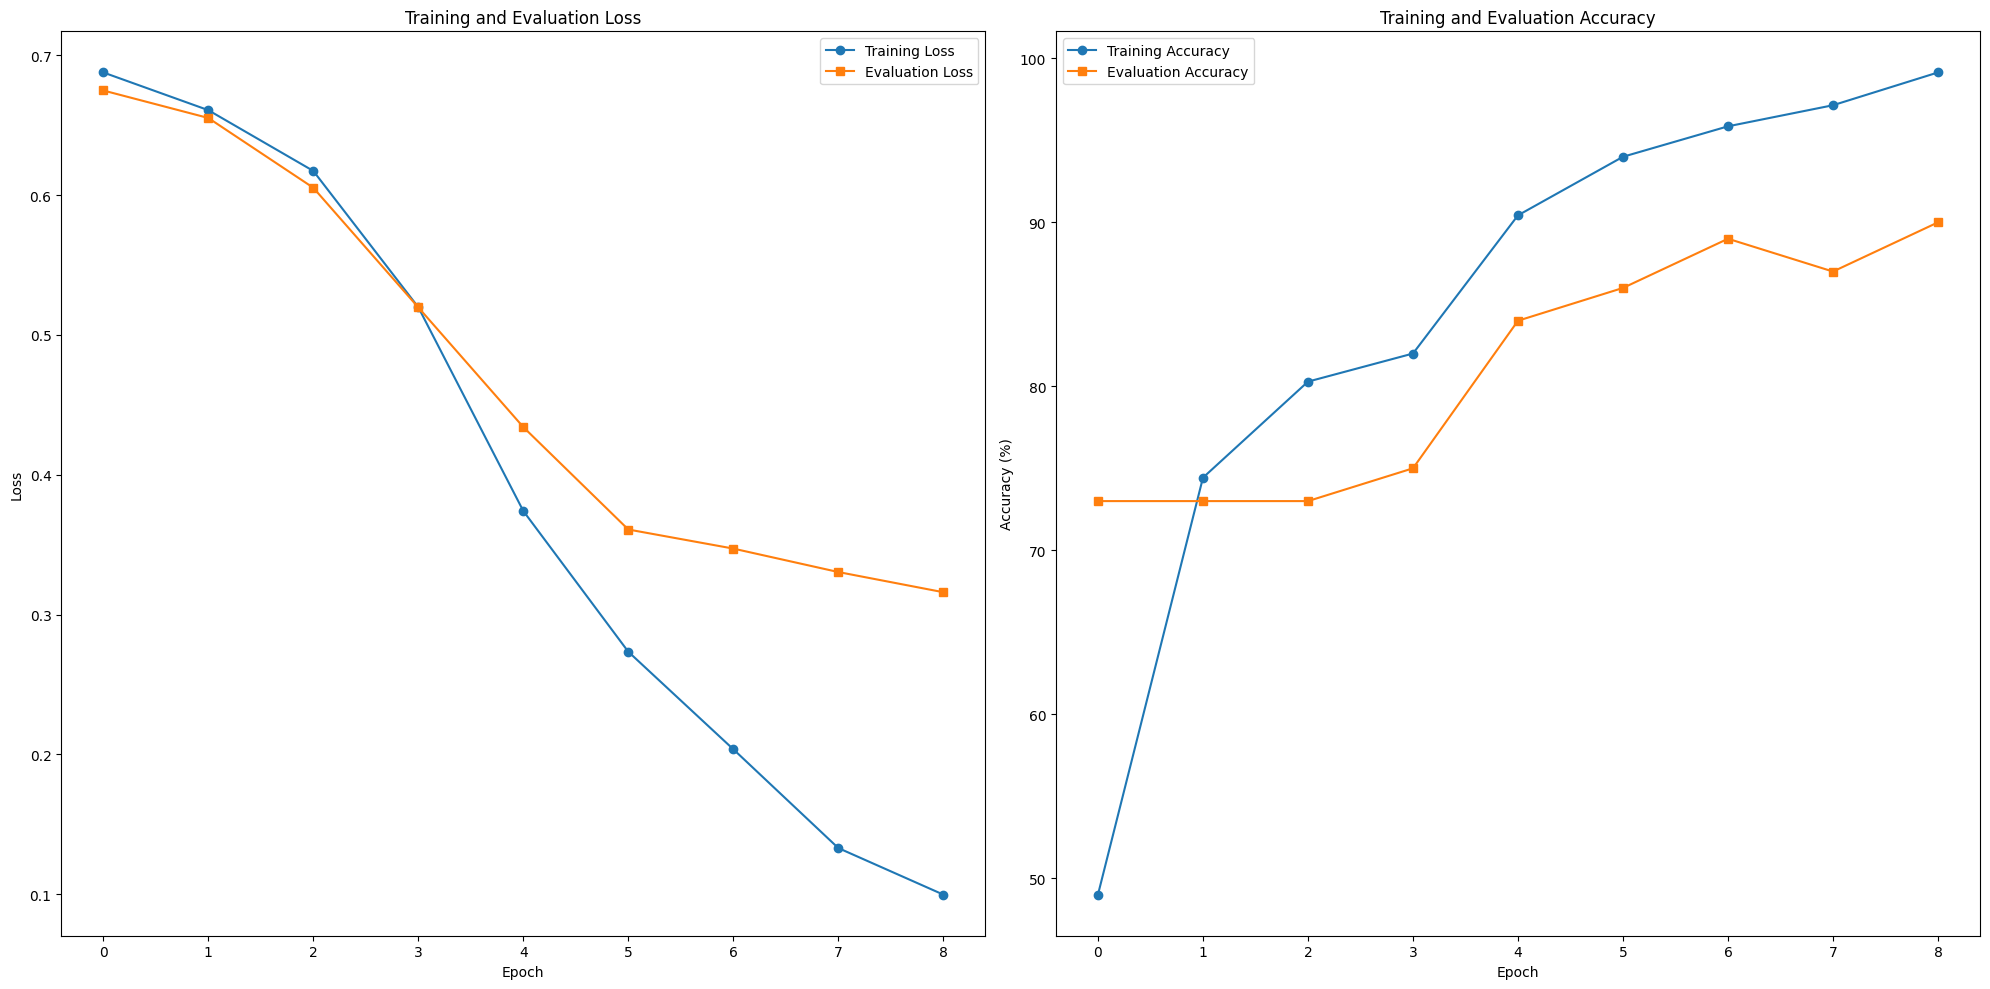

In [27]:
plot_train_eval(LSTM_train_losses, LSTM_train_accuracies, LSTM_eval_losses, LSTM_eval_accuracies)

## Q4: test and analyze the sesitivity to the change of the following parameters:

1. Sequence length
2. embedding size
3. LSTM hidden size
4. Dropout usage

In [ ]:
seq_lens = [30, 50, 100]embed_dims = [50, 100, 200]hidden_dims = [32, 64, 128]dropouts = [0.0, 0.3, 0.5]results = []for seq_len in seq_lens:    for embed_dim in embed_dims:        for hidden_dim in hidden_dims:            for dropout in dropouts:                # Regenerate sequences for new max_len                emails['input_ids'] = emails['processed_text_tokens'].apply(                    lambda tokens: tokens_to_indices(tokens, token2idx, seq_len)                )                # Resplit & reload data                train_df, temp_df = train_test_split(emails, test_size=0.3, stratify=emails['label'], random_state=42)                val_df, test_df = train_test_split(temp_df, test_size=2/3, stratify=temp_df['label'], random_state=42)                train_loader = DataLoader(EmailDataset(train_df), batch_size=64, shuffle=True)                val_loader = DataLoader(EmailDataset(val_df), batch_size=64)                test_loader = DataLoader(EmailDataset(test_df), batch_size=64)                # Model                model = LSTMClassifier(vocab_size=vocab_size, embed_dim=embed_dim, hidden_dim=hidden_dim, dropout=dropout).to(device)                loss_fn = nn.BCEWithLogitsLoss()                optimizer = torch.optim.Adam(model.parameters(), lr=0.001)                # Train & evaluate                train_losses, train_accuracies, eval_losses, eval_accuracies = train_validation(model, loss_fn, optimizer, train_loader, val_loader, device, epochs=9, show_result=False)                # Store results                results.append({                    'seq_len': seq_len,                    'embed_dim': embed_dim,                    'hidden_dim': hidden_dim,                    'dropout_rate': dropout,                    'val_accuracy': max(eval_accuracies)                })

Train time on cuda: 0.144 minutes




Train time on cuda: 0.123 minutes




Train time on cuda: 0.129 minutes




Train time on cuda: 0.119 minutes




Train time on cuda: 0.160 minutes




...

Train time on cuda: 0.035 minutes




Train time on cuda: 0.034 minutes




Train time on cuda: 0.036 minutes




Train time on cuda: 0.035 minutes




Train time on cuda: 0.036 minutes


